<a href="https://colab.research.google.com/github/srishti-bs/Statistical-Foundations-of-Data-Science/blob/main/KmeansCustomer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


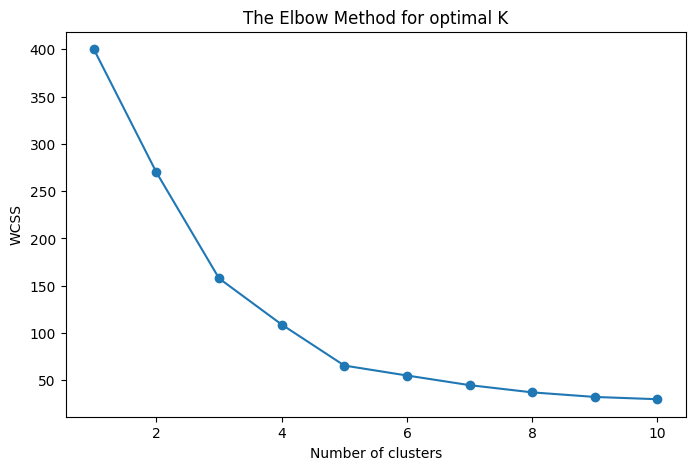

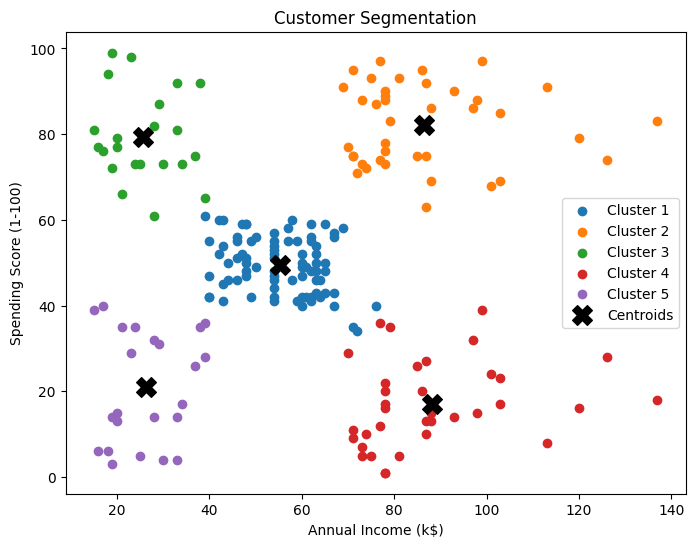


Cluster-wise Summary:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data=pd.read_csv("Mall_Customers.csv")
print(data.head())

x=data[['Annual Income (k$)','Spending Score (1-100)']]
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,random_state=42, n_init=10)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')

plt.title('The Elbow Method for optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kmeans=KMeans(n_clusters=5,random_state=42, n_init=10)
kmeans.fit(x_scaled)
clusters=kmeans.predict(x_scaled)
data['Cluster']=clusters

plt.figure(figsize=(8,6))
for cluster in range(5):
  plt.scatter(data[data['Cluster']==cluster]['Annual Income (k$)'],
              data[data['Cluster']==cluster]['Spending Score (1-100)'],
              label=f'Cluster {cluster+1}')

plt.scatter(scaler.inverse_transform(kmeans.cluster_centers_)[:,0],
            scaler.inverse_transform(kmeans.cluster_centers_)[:,1],
            s=200,
            c='black',
            marker='X',
            label='Centroids')

plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

print("\nCluster-wise Summary:")
print(data.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean())